In [1]:
# Install required packages (idempotent, safe to re-run)
import sys
!{sys.executable} -m pip install --quiet lightgbm scikit-learn pandas numpy matplotlib joblib

# EXP H Threshold Experiment

Threshold sweep for: `0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2` using the same EXP3 preprocessing/model bundle.

In [2]:
from pathlib import Path

import joblib
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ── Utility helpers (mirrors Main_2015_Training_Core + EXP3-B) ───────────────

def _find_col(columns, aliases):
    lc = {c.lower(): c for c in columns}
    for a in aliases:
        if a.lower() in lc:
            return lc[a.lower()]
    for c in columns:
        if any(a.lower() in c.lower() for a in aliases):
            return c
    return None

def _to_num(s):
    return pd.to_numeric(s, errors='coerce').replace([9, 99, 888888, 999999], np.nan)

def _build_smoking_level(df_):
    sl = _find_col(df_.columns, ['smoking_level'])
    if sl:
        return _to_num(df_[sl]).clip(0, 3).astype(float), [sl]
    ss  = _find_col(df_.columns, ['smoke_status'])
    cs  = _find_col(df_.columns, ['current_smoking', 'currentsmoking'])
    es  = _find_col(df_.columns, ['ever_smk'])
    used, out = [], pd.Series(np.nan, index=df_.index, dtype=float)
    if ss:
        status = _to_num(df_[ss]); used.append(ss)
        out[status == 0] = 0; out[status == 2] = 1; out[status == 1] = 2
        if cs:
            cur = _to_num(df_[cs]); used.append(cs)
            out[(status == 1) & (cur == 3)] = 3
        return out, used
    if cs:
        cur = _to_num(df_[cs]); used.append(cs)
        out[cur == 0] = 0; out[cur.isin([1, 2])] = 2; out[cur == 3] = 3
        return out, used
    if es:
        ever = _to_num(df_[es]); used.append(es)
        out[ever == 0] = 0; out[ever > 0] = 1
        return out, used
    return None, []

def _build_alcohol_level(df_):
    al = _find_col(df_.columns, ['alcohol_level'])
    if al:
        return _to_num(df_[al]).clip(0, 3).astype(float), [al]
    as_ = _find_col(df_.columns, ['alcohol_status'])
    bg  = _find_col(df_.columns, ['binge_drink', 'binge_drinking'])
    ca  = _find_col(df_.columns, ['con_alcohol'])
    d30 = _find_col(df_.columns, ['drnk_30days'])
    ae  = _find_col(df_.columns, ['alcohol'])
    used, out = [], pd.Series(np.nan, index=df_.index, dtype=float)
    if as_:
        status = _to_num(df_[as_]); used.append(as_)
        out[status == 0] = 0; out[status == 2] = 1; out[status == 1] = 2
        if bg:
            binge = _to_num(df_[bg]); used.append(bg)
            out[(status == 1) & (binge == 1)] = 3
        return out, used
    out[:] = 0
    if ae:
        ever = _to_num(df_[ae]);   used.append(ae);   out[ever > 0] = 1
    if ca:
        cur  = _to_num(df_[ca]);   used.append(ca);   out[cur == 1] = np.maximum(out[cur == 1], 2)
    if d30:
        d    = _to_num(df_[d30]);  used.append(d30);  out[d == 1]   = np.maximum(out[d == 1], 2)
    if bg:
        b    = _to_num(df_[bg]);   used.append(bg);   out[b == 1]   = 3
    return (out, used) if used else (None, [])

def _build_bmi(df_):
    w = _find_col(df_.columns, ['weight'])
    h = _find_col(df_.columns, ['height'])
    if not w or not h:
        return None, []
    wt = pd.to_numeric(df_[w], errors='coerce')
    ht = pd.to_numeric(df_[h], errors='coerce')
    if pd.notna(ht.median()) and float(ht.median()) > 3.0:
        ht = ht / 100.0
    return (wt / ht**2).replace([np.inf, -np.inf], np.nan).astype(float), [w, h]

def _build_whr(df_):
    wc = _find_col(df_.columns, ['waist'])
    hc = _find_col(df_.columns, ['hip'])
    if not wc or not hc:
        return None, []
    waist = pd.to_numeric(df_[wc], errors='coerce')
    hip   = pd.to_numeric(df_[hc], errors='coerce').replace(0, np.nan)
    return (waist / hip).replace([np.inf, -np.inf], np.nan).astype(float), [wc, hc]

# ── Merge from Datasets2015 (mirrors Main_2015_Training_Core merge logic) ─────
ROOT = Path.cwd()
DS   = ROOT / 'Datasets2015'

def _find_dataset(folder, hint=''):
    folder = Path(folder)
    cands  = sorted([
        p for p in folder.glob('*.csv')
        if 'data-set' in p.name.lower() and 'dictionary' not in p.name.lower()
    ])
    return next((p for p in cands if hint in p.name.lower()), cands[0] if cands else None)

KEY_PRIORITY = [
    ['enns_year', 'hhnum', 'member_code'],
    ['hhnum', 'member_code'],
    ['enns_year', 'hhnum'],
    ['hhnum'],
]

def _best_keys(left, right):
    for keys in KEY_PRIORITY:
        if all(k in left.columns and k in right.columns for k in keys):
            return keys
    return []

clin_path = _find_dataset(DS / 'Clinical',       'clinical')
diet_path = _find_dataset(DS / 'Dietary',         'dietary')
anth_path = _find_dataset(DS / 'Anthropometric',  'anthrop')

if clin_path is None:
    raise FileNotFoundError(f'Clinical CSV not found in {DS}/Clinical/')

clin_raw = pd.read_csv(clin_path, low_memory=False)
diet_raw = pd.read_csv(diet_path, low_memory=False) if diet_path else None
anth_raw = pd.read_csv(anth_path, low_memory=False) if anth_path else None

# Left-join dietary onto clinical
df = clin_raw.copy()
if diet_raw is not None:
    merge_keys = _best_keys(df, diet_raw)
    if not merge_keys:
        raise ValueError('No common merge keys between clinical and dietary.')
    diet_work = diet_raw.drop_duplicates(subset=merge_keys, keep='first')
    overlap   = [c for c in diet_work.columns if c in df.columns and c not in merge_keys]
    diet_work = diet_work.drop(columns=overlap, errors='ignore')
    df        = df.merge(diet_work, on=merge_keys, how='left')
    print(f'After dietary merge : {df.shape}  keys={merge_keys}')

# Left-join anthropometric onto result
if anth_raw is not None:
    merge_keys = _best_keys(df, anth_raw)
    if merge_keys:
        anth_work = anth_raw.drop_duplicates(subset=merge_keys, keep='first')
        overlap   = [c for c in anth_work.columns if c in df.columns and c not in merge_keys]
        anth_work = anth_work.rename(columns={c: f'{c}_anth' for c in overlap})
        df        = df.merge(anth_work, on=merge_keys, how='left')
        print(f'After anthro merge  : {df.shape}  keys={merge_keys}')

print(f'Final merged shape  : {df.shape}')

# ── Target engineering (Hypertension from SBP/DBP, mirrors Main_2015_Training_Core) ──
sbp_col = _find_col(df.columns, ['ave_sbp', 'sbp', 'systolic', 'sysbp'])
dbp_col = _find_col(df.columns, ['ave_dbp', 'dbp', 'diastolic', 'diabp'])

if sbp_col and dbp_col:
    sbp = pd.to_numeric(df[sbp_col], errors='coerce')
    dbp = pd.to_numeric(df[dbp_col], errors='coerce')
    df['Hypertension'] = ((sbp >= 140) | (dbp >= 90)).fillna(False).astype(int)
    TARGET_COL = 'Hypertension'
    print(f'Target created from {sbp_col}, {dbp_col}  (>=140/90 rule)')
else:
    TARGET_COL = _find_col(df.columns, ['hypertension', 'htn', 'target', 'label', 'outcome'])
    if TARGET_COL is None:
        raise ValueError(f'Cannot derive target. Columns: {list(df.columns[:30])}')
    print(f'Target column found : {TARGET_COL}')

df = df.dropna(subset=[TARGET_COL]).copy()
print('Class balance:', df[TARGET_COL].value_counts(normalize=True).round(3).to_dict())

# ── Feature engineering (mirrors EXP3-B) ─────────────────────────────────────
X_raw = df.drop(columns=[TARGET_COL]).copy()
y     = df[TARGET_COL].astype(int).copy()

smk, smk_src = _build_smoking_level(X_raw)
if smk is not None:
    X_raw['fe_smoking_level'] = smk

alc, alc_src = _build_alcohol_level(X_raw)
if alc is not None:
    X_raw['fe_alcohol_level'] = alc

bmi, bmi_src = _build_bmi(X_raw)
if bmi is not None:
    X_raw['bmi'] = bmi

whr, whr_src = _build_whr(X_raw)
if whr is not None:
    X_raw['whr'] = whr

# ── Drop non-predictive / raw source columns (mirrors EXP3-B manual_non_predictive) ──
DROP_ALWAYS = [
    sbp_col, dbp_col,
    'height', 'weight', 'waist', 'hip',
    'enns_year', 'hhnum', 'member_code',
    'regcode', 'provcode', 'psc', 'csc', 'rhc', 'psurec', 'strrec',
    'wgts', 'finalwgt', 'finalwgt1', 'finalwgt4',
    'rep_natl', 'rep_prov', 'ms_psucode', 'wrkplace',
    'interview_status', 'intdate', 'enumcode',
    'alcohol', 'con_alcohol', 'drnk_30days', 'drnk_30d_num', 'alcohol_status',
    'binge_drinking', 'current_smoking', 'ever_smk', 'smoke_status', 'smoking_level', 'alcohol_level',
]
DROP_ALWAYS += list(set(bmi_src + whr_src + smk_src + alc_src))
lc_map = {c.lower(): c for c in X_raw.columns}
to_drop = sorted({lc_map[d.lower()] for d in DROP_ALWAYS if d and d.lower() in lc_map})
X_raw = X_raw.drop(columns=to_drop, errors='ignore')

# Deduplicate age/sex alias columns from anthro join
for _alias in ['age', 'sex']:
    _cands = [c for c in X_raw.columns if _alias in c.lower()]
    if len(_cands) > 1:
        _keep  = next((c for c in _cands if c.lower() == _alias), _cands[0])
        X_raw  = X_raw.drop(columns=[c for c in _cands if c != _keep], errors='ignore')

X = X_raw.copy()
print(f'Features: {X.shape[1]}  | Rows: {len(X)}  | Positives: {int(y.sum())}')


After dietary merge : (151189, 63)  keys=['hhnum']
After anthro merge  : (151189, 80)  keys=['hhnum', 'member_code']
Final merged shape  : (151189, 80)
Target created from Ave_SBP, Ave_DBP  (>=140/90 rule)
Class balance: {0: 0.848, 1: 0.152}
Features: 55  | Rows: 151189  | Positives: 22988


In [4]:
# ── EXP3-B style preprocessing: 3-way split + KNN impute + StandardScaler + OHE ──
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def _ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

def e3_fit_imputers(X_tr, num_cols, cat_cols):
    knn = KNNImputer(n_neighbors=5)
    if num_cols:
        knn.fit(X_tr[num_cols])
    cat_imp = None
    if cat_cols:
        cat_imp = SimpleImputer(strategy='most_frequent')
        cat_imp.fit(X_tr[cat_cols])
    return knn, cat_imp

def e3_impute(knn, cat_imp, X_df, num_cols, cat_cols):
    frames = []
    if num_cols:
        frames.append(pd.DataFrame(knn.transform(X_df[num_cols]), columns=num_cols, index=X_df.index))
    if cat_cols and cat_imp is not None:
        frames.append(pd.DataFrame(cat_imp.transform(X_df[cat_cols]), columns=cat_cols, index=X_df.index))
    return pd.concat(frames, axis=1) if frames else pd.DataFrame(index=X_df.index)

def e3_fit_enc_scaler(X_imp, num_cols, cat_cols):
    scaler  = StandardScaler()
    ohe_enc = None
    if num_cols:
        scaler.fit(X_imp[num_cols])
    if cat_cols:
        ohe_enc = _ohe()
        ohe_enc.fit(X_imp[cat_cols].astype(str))
    return scaler, ohe_enc

def e3_encode(scaler, ohe_enc, X_imp, num_cols, cat_cols):
    parts = []
    if num_cols:
        parts.append(scaler.transform(X_imp[num_cols]))
    if cat_cols and ohe_enc is not None:
        parts.append(ohe_enc.transform(X_imp[cat_cols].astype(str)))
    return np.hstack(parts) if parts else np.empty((len(X_imp), 0))

# 3-way split: 60% train, 20% cal, 20% test (mirrors EXP3-B)
X_tr_raw, X_tmp_raw, y_train, y_tmp = train_test_split(
    X, y, test_size=0.40, random_state=42, stratify=y
)
X_cal_raw, X_test_raw, y_cal, y_test = train_test_split(
    X_tmp_raw, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp
)

# Always treat these as categorical for SMOTENC, even if numeric
force_cat = ['fe_smoking_level', 'fe_alcohol_level']
# Try to find an ethnicity column (case-insensitive, partial match)
ethnicity_col = next((c for c in X_tr_raw.columns if 'ethnic' in c.lower()), None)
if ethnicity_col:
    force_cat.append(ethnicity_col)

e3_num_cols = X_tr_raw.select_dtypes(include=[np.number]).columns.tolist()
e3_cat_cols = [c for c in X_tr_raw.columns if c not in e3_num_cols or c in force_cat]
e3_num_cols = [c for c in e3_num_cols if c not in force_cat]

# Fit on train only, transform all splits
knn_imp, cat_imp_h = e3_fit_imputers(X_tr_raw, e3_num_cols, e3_cat_cols)
X_tr_imp  = e3_impute(knn_imp, cat_imp_h, X_tr_raw,   e3_num_cols, e3_cat_cols)
X_cal_imp = e3_impute(knn_imp, cat_imp_h, X_cal_raw,  e3_num_cols, e3_cat_cols)
X_te_imp  = e3_impute(knn_imp, cat_imp_h, X_test_raw, e3_num_cols, e3_cat_cols)

scaler_h, ohe_h = e3_fit_enc_scaler(X_tr_imp, e3_num_cols, e3_cat_cols)

# Encoded matrices ready for LightGBM
X_tr_enc  = e3_encode(scaler_h, ohe_h, X_tr_imp,  e3_num_cols, e3_cat_cols)
X_cal_enc = e3_encode(scaler_h, ohe_h, X_cal_imp, e3_num_cols, e3_cat_cols)
X_te_enc  = e3_encode(scaler_h, ohe_h, X_te_imp,  e3_num_cols, e3_cat_cols)

print(pd.DataFrame({
    'Split':  ['Train', 'Cal', 'Test'],
    'N':      [len(y_train), len(y_cal), len(y_test)],
    'Pos%':   [f"{y_train.mean()*100:.1f}", f"{y_cal.mean()*100:.1f}", f"{y_test.mean()*100:.1f}"],
    'Shape':  [str(X_tr_enc.shape), str(X_cal_enc.shape), str(X_te_enc.shape)],
}).to_string(index=False))


Split     N Pos%       Shape
Train 90713 15.2 (90713, 64)
  Cal 30238 15.2 (30238, 64)
 Test 30238 15.2 (30238, 64)


In [5]:
# ── LightGBM (GPU) rigorous threshold sweep ───────────────────────────────────
# Train with StratifiedKFold + GridSearchCV, then sweep thresholds on held-out test set.
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.utils import resample as sk_resample

# Oversample minority class in training set
X_maj = X_tr_enc[y_train.values == 0]
X_min = X_tr_enc[y_train.values == 1]
y_maj = y_train.values[y_train.values == 0]
y_min = y_train.values[y_train.values == 1]

X_min_up, y_min_up = sk_resample(X_min, y_min, replace=True, n_samples=len(X_maj), random_state=42)
X_bal = np.vstack([X_maj, X_min_up])
y_bal = np.concatenate([y_maj, y_min_up])

# LightGBM with GPU
lgbm = lgb.LGBMClassifier(
    objective='binary', device='gpu',
    gpu_platform_id=0, gpu_device_id=0,
    metric='binary_logloss', verbosity=-1,
    random_state=42,
)

param_grid = {
    'num_leaves':    [15, 31, 63],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5, 7],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs = GridSearchCV(lgbm, param_grid, scoring='f1', cv=cv, n_jobs=-1, verbose=1)
gs.fit(X_bal, y_bal)

print('Best params:', gs.best_params_)
print('Best CV F1 :', round(gs.best_score_, 4))

# Threshold sweep on held-out test set
proba = gs.best_estimator_.predict_proba(X_te_enc)[:, 1]
thresholds = [0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2]
rows = []
for th in thresholds:
    pred = (proba >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    rows.append({
        'threshold': th,
        'accuracy':  accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall':    recall_score(y_test, pred, zero_division=0),
        'f1':        f1_score(y_test, pred, zero_division=0),
        'specificity': specificity,
        'tp': int(tp), 'fp': int(fp), 'tn': int(tn), 'fn': int(fn),
    })

threshold_df = pd.DataFrame(rows).sort_values('threshold', ascending=False).reset_index(drop=True)
threshold_df

Fitting 5 folds for each of 54 candidates, totalling 270 fits


KeyboardInterrupt: 

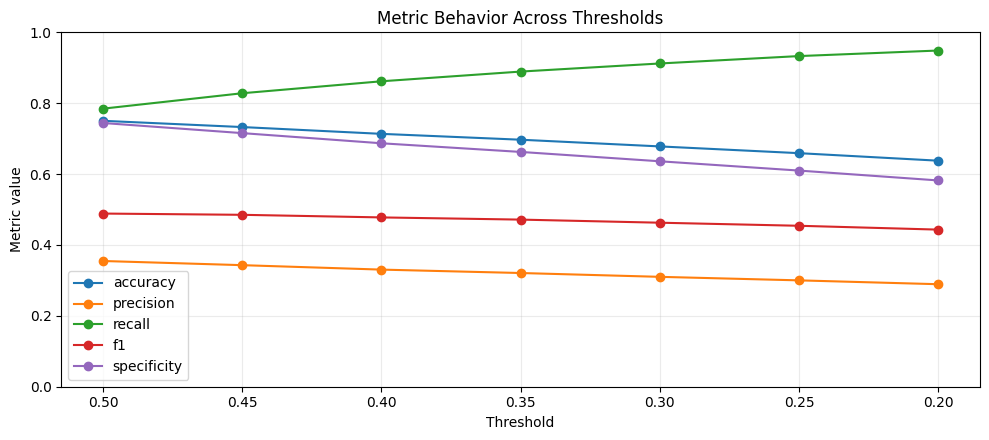

In [ ]:
plt.figure(figsize=(10, 4.5))
for metric in ['accuracy', 'precision', 'recall', 'f1', 'specificity']:
    plt.plot(threshold_df['threshold'], threshold_df[metric], marker='o', label=metric)
plt.gca().invert_xaxis()
plt.ylim(0.0, 1.0)
plt.xlabel('Threshold')
plt.ylabel('Metric value')
plt.title('LightGBM (GPU) Metric Behavior Across Thresholds')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 4.5))
for metric in ['accuracy', 'precision', 'recall', 'f1', 'specificity']:
    plt.plot(lgbm_threshold_df['threshold'], lgbm_threshold_df[metric], marker='o', label=metric)
plt.gca().invert_xaxis()
plt.ylim(0.0, 1.0)
plt.xlabel('Threshold')
plt.ylabel('Metric value')
plt.title('LightGBM (GPU) Metric Behavior Across Thresholds')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'lgbm_threshold_df' is not defined

<Figure size 1000x450 with 0 Axes>